In [9]:
import os
import pandas as pd

In [10]:

# Caminho da pasta com os CSVs
pasta = "./tests/results"

# Listas para médias
rows = []

In [11]:
# Ler todos os CSV da pasta
for arquivo in os.listdir(pasta):
    if arquivo.endswith('.csv'):
        parts = arquivo.split('-')
        broadphase = '_'.join(parts[2:4])
        collision = parts[4]
        count = parts[5]

        if count.isnumeric() == False:
            continue

        caminho = os.path.join(pasta, arquivo)

        df = pd.read_csv(caminho)
        rows.append([df["collisions_test"].mean(), df["true_collisions"].mean(), int(count), broadphase, collision])

In [12]:

df = pd.DataFrame(rows, columns=["collisions_test", "true_collisions", "count", "broadphase", "collision"])


In [13]:
# Agrupar por broadphase e collision
groups = df.groupby(["broadphase", "collision"])

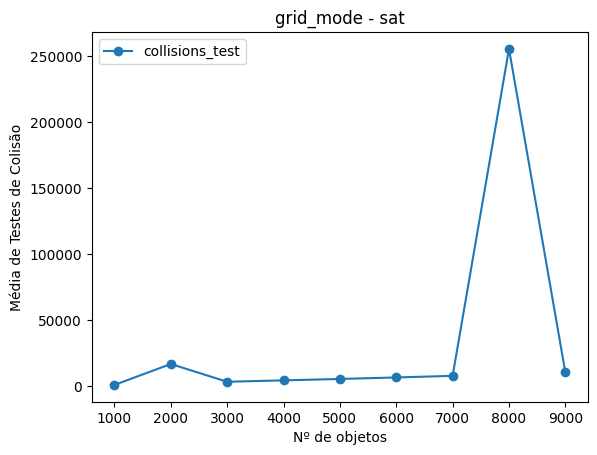

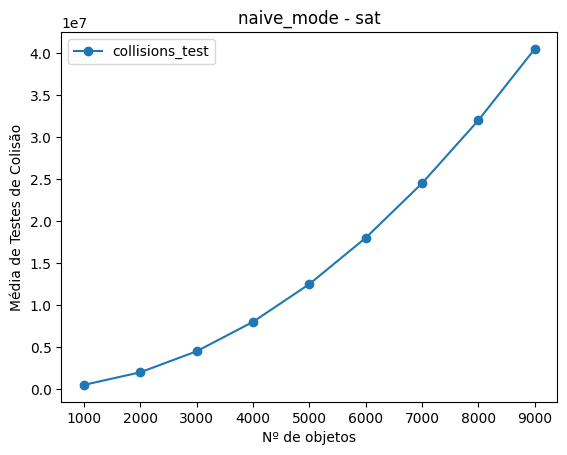

In [16]:
# Gerar um gráfico para cada grupo
for (broadphase, collision), g in groups:
    g = g.sort_values("count")

    g.plot(x="count", y=["collisions_test"], kind="line", marker="o", title=f"{broadphase} - {collision}", xlabel="Nº de objetos", ylabel="Média de Testes de Colisão")